In [1]:
import scanpy as sc
from CODA.Alignment import *
from CODA.RGBgenerator import *
from CODA.Cross_correlation import *
from CODA.utils import *
from CODA.Preprocessing import *

D:\anaconda\envs\CODA\lib\site-packages\CODA\Common_domain.py:220: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
ST1 = sc.read_h5ad('ST1.h5ad')
ST2 = sc.read_h5ad('ST2.h5ad')

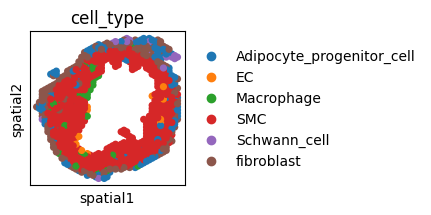

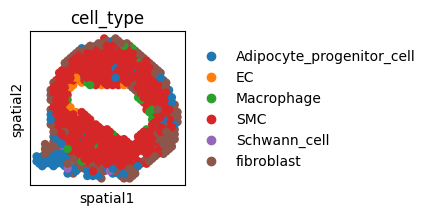

In [3]:
plt.rcParams['figure.figsize'] = [2,2]
sc.pl.embedding(ST1,basis='spatial', color='cell_type')
sc.pl.embedding(ST2, basis='spatial', color='cell_type')

# Preprocessing : Integration and dimension reduction

D:\anaconda\envs\CODA\lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 3000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


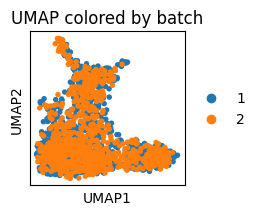

In [4]:
embedding_ST1, embedding_ST2 = dimension_reduction(ST1,ST2,reduction_dim=3,method='umap')

# Global alignment

In [5]:
spatial_ST1_normalized = normalization(ST1.obsm['spatial'])
spatial_ST2_normalized = normalization(ST2.obsm['spatial'])
ST2.obsm['spatial_norm'] = spatial_ST2_normalized

In [6]:
R, t = global_alignment(spatial_ST1_normalized, spatial_ST2_normalized, embedding_ST1,embedding_ST2)
transformed_coords = np.dot(spatial_ST1_normalized, R) + t
ST1.obsm['aligned_spatial'] = transformed_coords

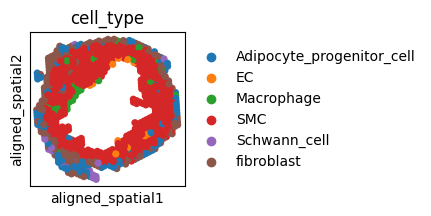

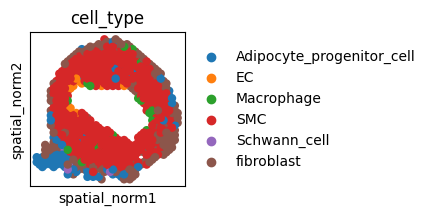

In [7]:
sc.pl.embedding(ST1,basis='aligned_spatial', color='cell_type')
sc.pl.embedding(ST2, basis='spatial_norm', color='cell_type')

# Generation of Images

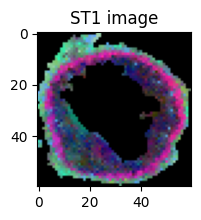

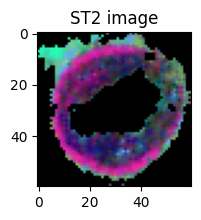

In [8]:
coords_ST1 = ST1.obsm['aligned_spatial']
ST1_generator = RGBImageGenerator(img_size=(60,60))
img_ST1, mapping_ST1 = ST1_generator.create_rgb_image_with_mapping(coords_ST1, embedding_ST1*255)
img_ST1_interpolated = ST1_generator.interpolate_zero_pixels(img_ST1)
ST1_generator.show_image(img_ST1_interpolated,title='ST1 image')

coords_ST2 = ST2.obsm['spatial_norm']
ST2_generator = RGBImageGenerator(img_size=(60,60))
img_ST2, mapping_ST2 = ST2_generator.create_rgb_image_with_mapping(coords_ST2, embedding_ST2*255)
img_ST2_interpolated = ST2_generator.interpolate_zero_pixels(img_ST2)
ST2_generator.show_image(img_ST2_interpolated,title='ST2 image')

# Local alignment

In [9]:
img_ST1_normalized = img_ST1_interpolated.astype(np.float32) / 255.0
img_ST2_normalized = img_ST2_interpolated.astype(np.float32) / 255.0

lddmm = LDDMM(grid_shape=(60, 60))
aligned_image, v_hat, energies, length, Phi0, Phi1, J0, J1 = lddmm.run_alignment(img_ST1_normalized, img_ST2_normalized, alpha=1, gamma=1, steps=32, max_iter=50, sigma=0.2,  lr=0.001)

Iter 000 | Total 22598.54 | Reg 0.00 | Match 22598.54
Iter 001 | Total 16255.27 | Reg 39.99 | Match 16215.27
Iter 002 | Total 13370.52 | Reg 68.49 | Match 13302.03
Iter 003 | Total 11531.27 | Reg 91.65 | Match 11439.61
Iter 004 | Total 10396.09 | Reg 110.94 | Match 10285.15
Iter 005 | Total 9372.72 | Reg 127.49 | Match 9245.22
Iter 006 | Total 8604.58 | Reg 141.81 | Match 8462.77
Iter 007 | Total 7995.14 | Reg 154.41 | Match 7840.73
Iter 008 | Total 7561.67 | Reg 165.94 | Match 7395.73
Iter 009 | Total 7102.16 | Reg 176.65 | Match 6925.50
Iter 010 | Total 6847.89 | Reg 186.68 | Match 6661.21
Iter 011 | Total 6621.10 | Reg 196.20 | Match 6424.90
Iter 012 | Total 6407.37 | Reg 205.11 | Match 6202.26
Iter 013 | Total 6263.82 | Reg 213.50 | Match 6050.32
Iter 014 | Total 6095.64 | Reg 221.47 | Match 5874.17
Iter 015 | Total 5888.99 | Reg 229.11 | Match 5659.88
Iter 016 | Total 5703.27 | Reg 236.44 | Match 5466.82
Iter 017 | Total 5576.92 | Reg 243.49 | Match 5333.43
Iter 018 | Total 5512.5

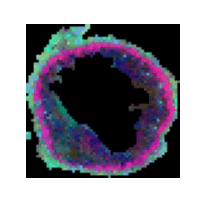

In [10]:
generate_gif_from_sequence(J0, gif_path="output/J0_demo.gif", duration=80)

In [11]:
mapped_img_ST1, new_coords_ST1 = direct_image_mapping_with_coords(img_ST1,Phi1[0], mapping_ST1)
ST1.obsm['fine_aligned_spatial'] = new_coords_ST1
cell_positions_in_img_ST2 = find_cell_positions_in_image(coords_ST2, img_size=(60, 60))
ST2.obsm['spatial_image'] = cell_positions_in_img_ST2

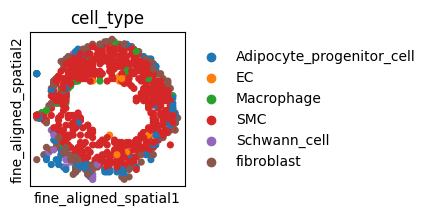

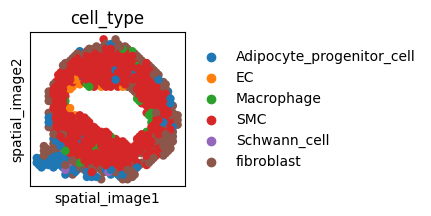

In [12]:
# Slices after local alignment
sc.pl.embedding(ST1, basis='fine_aligned_spatial', color='cell_type')
sc.pl.embedding(ST2, basis='spatial_image', color='cell_type')

# Spatial analysis

In [13]:
scc = SpatialCrossCorrelation(ST1, ST2,
                              coord_key_1='fine_aligned_spatial',
                              coord_key_2='spatial_image',
                              beta=1.0)

results = scc.compute_cross_correlation()

for gene, score in results[:10]:
    print(f"{gene}\t{score:.4f}")

MYL9	0.4272
TAGLN	0.3816
FN1	0.3589
APOD	0.2843
ACTA2	0.2817
TPM2	0.2756
C7	0.2638
G0S2	0.2471
LINC00632	0.2441
AEBP1	0.2383
